In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df=pd.read_csv('C:\\Users\\Admin\\OneDrive\\Desktop\\data science\\ML\\SUPERVISED LEARNING\\Dataset\\student_performance.csv')

In [3]:
#df['Extracurricular Activities'].unique()

df['Extracurricular Activities'] = df['Extracurricular Activities'].map({
    'Yes': 1,
    'No': 0
})

In [4]:
'''without mansion every columns we use like this drop target column'''

x = df.drop(columns='Performance Index')
y = df['Performance Index']

In [5]:
'''this giving every columns'''
# x = df[['Hours Studied',
#         'Previous Scores',
#         'Extracurricular Activities',
#         'Sleep Hours',
#         'Sample Question Papers Practiced']]

# y = df['Performance Index']

'this giving every columns'

In [6]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

In [7]:
df.corr(numeric_only=True)['Performance Index']

Hours Studied                       0.373730
Previous Scores                     0.915189
Extracurricular Activities          0.024525
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Performance Index                   1.000000
Name: Performance Index, dtype: float64

performance index and previous scores only strongly correlated

In [8]:
model = LinearRegression()

model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
model.intercept_

np.float64(-33.9219462155561)

In [10]:
model.coef_

array([2.85248393, 1.0169882 , 0.60861668, 0.47694148, 0.19183144])

In [11]:
ytrain_predicted = model.predict(xtrain)

In [12]:
ytrain_predicted

array([34.47064278, 25.69665091, 57.88131903, ..., 45.05542174,
       21.02145642, 22.57711635], shape=(8000,))

In [13]:
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

In [14]:
ytrain - ytrain_predicted 

9254    1.529357
1561   -0.696651
1670    1.118681
6087    0.382041
6669   -0.988844
          ...   
5734    3.631411
5191   -0.511155
5390   -1.055422
860    -1.021456
7270    1.422884
Name: Performance Index, Length: 8000, dtype: float64

In [15]:
new_input = pd.DataFrame({
    'Hours Studied': [5],
    'Previous Scores': [80],
    'Extracurricular Activities': [1],
    'Sleep Hours': [7],
    'Sample Question Papers Practiced': [4]
})

prediction = model.predict(new_input)


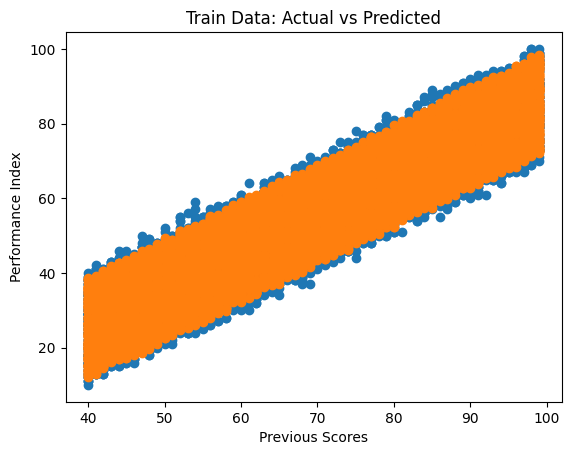

In [16]:
import matplotlib.pyplot as plt

# Train Data
# Actual input and output
plt.scatter(xtrain['Previous Scores'], ytrain)

# Actual input and predicted output
plt.scatter(xtrain['Previous Scores'], ytrain_predicted)

plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.title('Train Data: Actual vs Predicted')
plt.show()

# Conclusion
predicted values are very close to the actual values.

This shows that the model has learned well and is performing good on the training data.

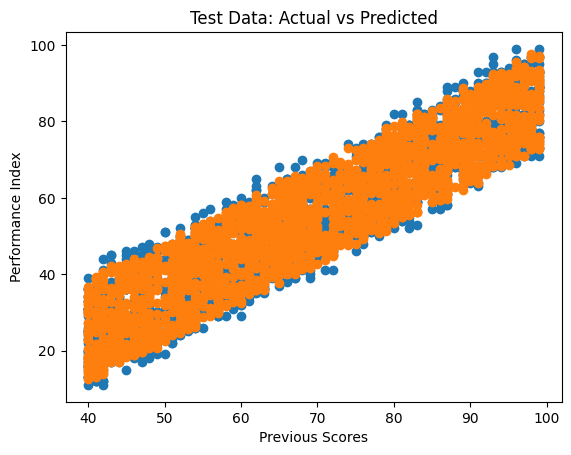

In [17]:
import matplotlib.pyplot as plt

# Predict test data
ytest_predicted = model.predict(xtest)

# Test Data
# Actual input and output
plt.scatter(xtest['Previous Scores'], ytest)

# Actual input and predicted output
plt.scatter(xtest['Previous Scores'], ytest_predicted)

plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.title('Test Data: Actual vs Predicted')
plt.show()

# conclusion
The predicted values are very close to the actual values.
This shows that the model performs well on new, unseen data.

In [18]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [19]:
train_score = r2_score(ytrain,ytrain_predicted)
test_score = r2_score(ytest,ytest_predicted)

print(f"Train score : {train_score}")
print(f"Test score : {test_score}")      #unseen data

Train score : 0.9886898790682355
Test score : 0.9889832909573145


In [20]:
mean_squared_error(ytrain,ytrain_predicted)

4.169735849525008

In [21]:
mean_absolute_error(ytrain,ytrain_predicted)

1.6193054830334277

In [22]:
root_mean_squared_error(ytrain,ytrain_predicted)

2.041993107119857